### BMI CALCULATOR

Linear sequential workflow that takes height and weight as input, calculates BMI and displays the result.

In [15]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict

In [16]:
# define state class (includes input and output variables and their types)
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float
    
# create graph object and pass state class as parameter 
graph = StateGraph(BMIState)

# define function
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = round(state['weight_kg'] / (state['height_m']**2), 2)
    return state

# add node and map it to function
graph.add_node('calculate_bmi', calculate_bmi)

# add edges
graph.add_edge(START, 'calculate_bmi') 
graph.add_edge('calculate_bmi', END)

# compile graph
bmi_calculator = graph.compile()

# execute the graph
bmi_calculator.invoke({
    "weight_kg": 57,
    "height_m": 1.63
})

{'height_m': 1.63, 'weight_kg': 57, 'bmi': 21.45}

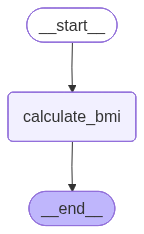

In [17]:
# to view graph structure
from IPython.display import Image
Image(bmi_calculator.get_graph().draw_mermaid_png())

### BMI Calculator with Category

In [18]:
# define state class (includes input and output variables and their types)
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float
    category: str
    
# create graph object and pass state class as parameter 
graph = StateGraph(BMIState)

# define functions
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = round(state['weight_kg'] / (state['height_m']**2), 2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
    return state
    

# add node and map it to function
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges
graph.add_edge(START, 'calculate_bmi') 
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile graph
bmi_calculator = graph.compile()

# execute the graph
bmi_calculator.invoke({
    "weight_kg": 57,
    "height_m": 1.63
})

{'height_m': 1.63, 'weight_kg': 57, 'bmi': 21.45, 'category': 'Normal'}

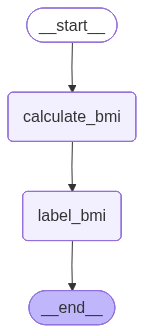

In [19]:
# to view graph structure
from IPython.display import Image
Image(bmi_calculator.get_graph().draw_mermaid_png())